# MABe 2022 Mouse Triplets - Data Analysis & Visualization

Dataset: `user_train_r1.npy` (1600 sequences, 30Hz, 60s each)  
Source: [MABe 2022 Mouse Triplets](https://www.aicrowd.com/challenges/multi-agent-behavior-challenge-2022/problems/mabe-2022-mouse-triplets)  

**Vocabulary**: `chases` (frame-level), `lights` (sequence-level)  
**Keypoints**: 12 body parts × 3 mice × (x, y), 850×850 pixel space

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import animation, rc
from collections import defaultdict
import os, sys

rc('animation', html='jshtml')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [2]:
DATA_PATH = 'data/mice/user_train_r1.npy'
raw = np.load(DATA_PATH, allow_pickle=True).item()
vocab = raw['vocabulary']
seqs  = raw['sequences']
seq_ids = list(seqs.keys())

print(f'Vocabulary: {vocab}')
print(f'Number of sequences: {len(seq_ids)}')
print(f'Keypoints shape (per seq): {np.array(seqs[seq_ids[0]]["keypoints"]).shape}')
print(f'Annotations: {[vocab[i] for i in range(len(vocab))]}')

Vocabulary: ['chases', 'lights']
Number of sequences: 1600
Keypoints shape (per seq): (1800, 3, 12, 2)
Annotations: ['chases', 'lights']


## 1. Keypoint Layout & Body Part Reference

12 body parts (0-indexed):  
0-nose, 1-left_ear, 2-right_ear, 3-neck, 4-left_forepaw, 5-right_forepaw,  
6-center_back, 7-left_hindpaw, 8-right_hindpaw, 9-tail_base, 10-tail_middle, 11-tail_tip

In [3]:
BODY_PARTS = ['nose', 'left_ear', 'right_ear', 'neck', 'left_forepaw', 'right_forepaw',
              'center_back', 'left_hindpaw', 'right_hindpaw', 'tail_base', 'tail_middle', 'tail_tip']

SKELETON = [(0,1),(1,3),(3,2),(2,0),   # head
            (3,6),(6,9),                # midline
            (9,10),(10,11),             # tail
            (4,5),(5,8),(8,9),(9,7),(7,4)]  # legs

MOUSE_COLORS = ['#32CD32', '#87CEEB', '#FF6347']  # green, blue, red
MOUSE_NAMES  = ['Mouse 0', 'Mouse 1', 'Mouse 2']

## 2. Annotation Distribution

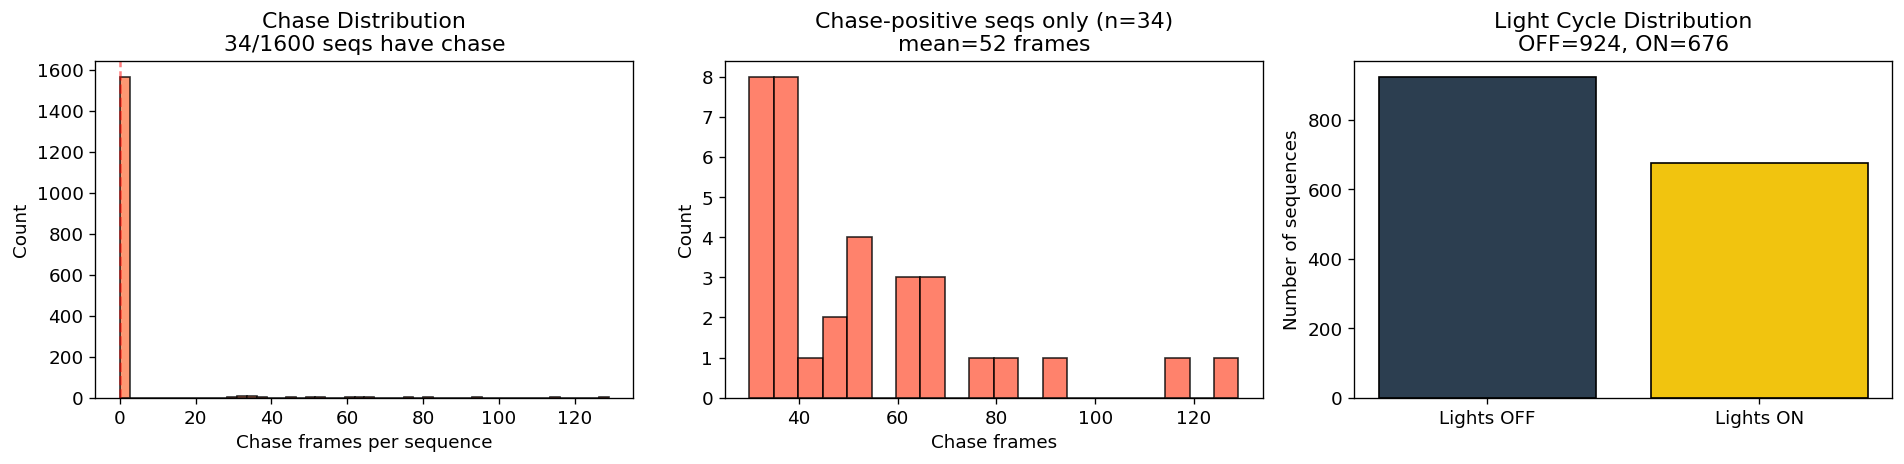

Chase: 1762 total frames across 34 sequences
  = 0.0612% of all frames
Light: 924 OFF / 676 ON sequences (57.8% / 42.2%)


In [4]:
chase_per_seq  = []
light_per_seq  = []

for sid in seq_ids:
    ann = seqs[sid]['annotations']
    chase_per_seq.append(np.sum(np.array(ann[0]) == 1))
    light_per_seq.append(np.array(ann[1])[0])  # sequence-level

chase_per_seq = np.array(chase_per_seq)
light_per_seq = np.array(light_per_seq)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Chase distribution
axes[0].hist(chase_per_seq, bins=50, color='coral', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Chase frames per sequence')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Chase Distribution\n{np.sum(chase_per_seq>0)}/{len(seq_ids)} seqs have chase')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)

# Chase vs non-chase (zoom to positive)
chase_positive = chase_per_seq[chase_per_seq > 0]
if len(chase_positive) > 0:
    axes[1].hist(chase_positive, bins=20, color='tomato', edgecolor='black', alpha=0.8)
    axes[1].set_xlabel('Chase frames')
    axes[1].set_ylabel('Count')
    axes[1].set_title(f'Chase-positive seqs only (n={len(chase_positive)})\nmean={np.mean(chase_positive):.0f} frames')

# Light cycle
n_on = np.sum(light_per_seq == 1)
n_off = np.sum(light_per_seq == 0)
axes[2].bar(['Lights OFF', 'Lights ON'], [n_off, n_on], color=['#2c3e50', '#f1c40f'], edgecolor='black')
axes[2].set_ylabel('Number of sequences')
axes[2].set_title(f'Light Cycle Distribution\nOFF={n_off}, ON={n_on}')

plt.tight_layout()
plt.show()

print(f'Chase: {np.sum(chase_per_seq)} total frames across {np.sum(chase_per_seq>0)} sequences')
print(f'  = {np.sum(chase_per_seq)/(len(seq_ids)*1800)*100:.4f}% of all frames')
print(f'Light: {n_off} OFF / {n_on} ON sequences ({n_off/(n_off+n_on)*100:.1f}% / {n_on/(n_off+n_on)*100:.1f}%)')

## 3. Kinematic Feature Extraction

Since only `chases` and `lights` are annotated, we derive richer behavior signals from kinematics:  
- **Speed** (per mouse): displacement of center-back keypoint
- **Inter-mouse distance**: pairwise distance between mouse centers
- **Heading angle**: nose → tail_base direction
- **Body elongation**: nose-to-tail_base distance (proxy for posture)
- **Relative orientation**: whether mice face each other

In [5]:
def compute_kinematics(kp):
    """Compute per-frame kinematics from keypoints (1800, 3, 12, 2)."""
    T, M = kp.shape[0], kp.shape[1]
    center = kp[:, :, 6, :]  # center_back as body center (1800, 3, 2)
    nose   = kp[:, :, 0, :]
    tail   = kp[:, :, 9, :]
    
    # Speed: frame-to-frame displacement of center_back
    speed = np.zeros((T, M))
    speed[1:] = np.linalg.norm(np.diff(center, axis=0), axis=2)
    
    # Inter-mouse distance (pairwise)
    pair_dist = np.zeros((T, 3))  # (0-1, 0-2, 1-2)
    idx = 0
    pair_names = []
    for i in range(M):
        for j in range(i+1, M):
            pair_dist[:, idx] = np.linalg.norm(center[:, i] - center[:, j], axis=1)
            pair_names.append(f'M{i}-M{j}')
            idx += 1
    
    # Heading: angle from tail_base to nose
    heading_vec = nose - tail  # (1800, 3, 2)
    heading_angle = np.arctan2(heading_vec[:,:,1], heading_vec[:,:,0])  # (1800, 3)
    
    # Body elongation: nose-to-tail distance
    elongation = np.linalg.norm(heading_vec, axis=2)  # (1800, 3)
    
    # Angular velocity
    ang_vel = np.zeros((T, M))
    dangle = np.diff(heading_angle, axis=0)
    dangle = (dangle + np.pi) % (2*np.pi) - np.pi  # wrap to [-pi, pi]
    ang_vel[1:] = np.abs(dangle)
    
    return {
        'speed': speed, 'pair_dist': pair_dist, 'pair_names': pair_names,
        'heading_angle': heading_angle, 'elongation': elongation, 'ang_vel': ang_vel,
        'center': center
    }

In [6]:
# Compute kinematics across a sample of sequences
N_SAMPLE = 200
np.random.seed(42)
sample_ids = np.random.choice(seq_ids, size=min(N_SAMPLE, len(seq_ids)), replace=False)

all_speed, all_dist, all_elong, all_angvel = [], [], [], []
all_speed_chase, all_speed_nochase = [], []
all_dist_chase, all_dist_nochase = [], []
all_speed_lighton, all_speed_lightoff = [], []

for sid in sample_ids:
    kp = np.array(seqs[sid]['keypoints']).astype(float)
    ann_chase = np.array(seqs[sid]['annotations'][0])
    ann_light = np.array(seqs[sid]['annotations'][1])
    kin = compute_kinematics(kp)
    
    all_speed.append(kin['speed'].flatten())
    all_dist.append(kin['pair_dist'].flatten())
    all_elong.append(kin['elongation'].flatten())
    all_angvel.append(kin['ang_vel'].flatten())
    
    chase_mask = (ann_chase == 1)
    nochase_mask = (ann_chase == 0)
    
    if chase_mask.any():
        all_speed_chase.append(kin['speed'][chase_mask].flatten())
        all_dist_chase.append(kin['pair_dist'][chase_mask].flatten())
    all_speed_nochase.append(kin['speed'][nochase_mask].flatten())
    all_dist_nochase.append(kin['pair_dist'][nochase_mask].flatten())
    
    if ann_light[0] == 1:
        all_speed_lighton.append(kin['speed'].flatten())
    else:
        all_speed_lightoff.append(kin['speed'].flatten())

all_speed = np.concatenate(all_speed)
all_dist = np.concatenate(all_dist)
all_elong = np.concatenate(all_elong)
all_angvel = np.concatenate(all_angvel)
all_speed_nochase = np.concatenate(all_speed_nochase)
all_dist_nochase = np.concatenate(all_dist_nochase)
if all_speed_chase:
    all_speed_chase = np.concatenate(all_speed_chase)
    all_dist_chase = np.concatenate(all_dist_chase)
if all_speed_lighton:
    all_speed_lighton = np.concatenate(all_speed_lighton)
if all_speed_lightoff:
    all_speed_lightoff = np.concatenate(all_speed_lightoff)

print(f'Computed kinematics for {len(sample_ids)} sequences')

Computed kinematics for 200 sequences


## 4. Overall Kinematic Distributions

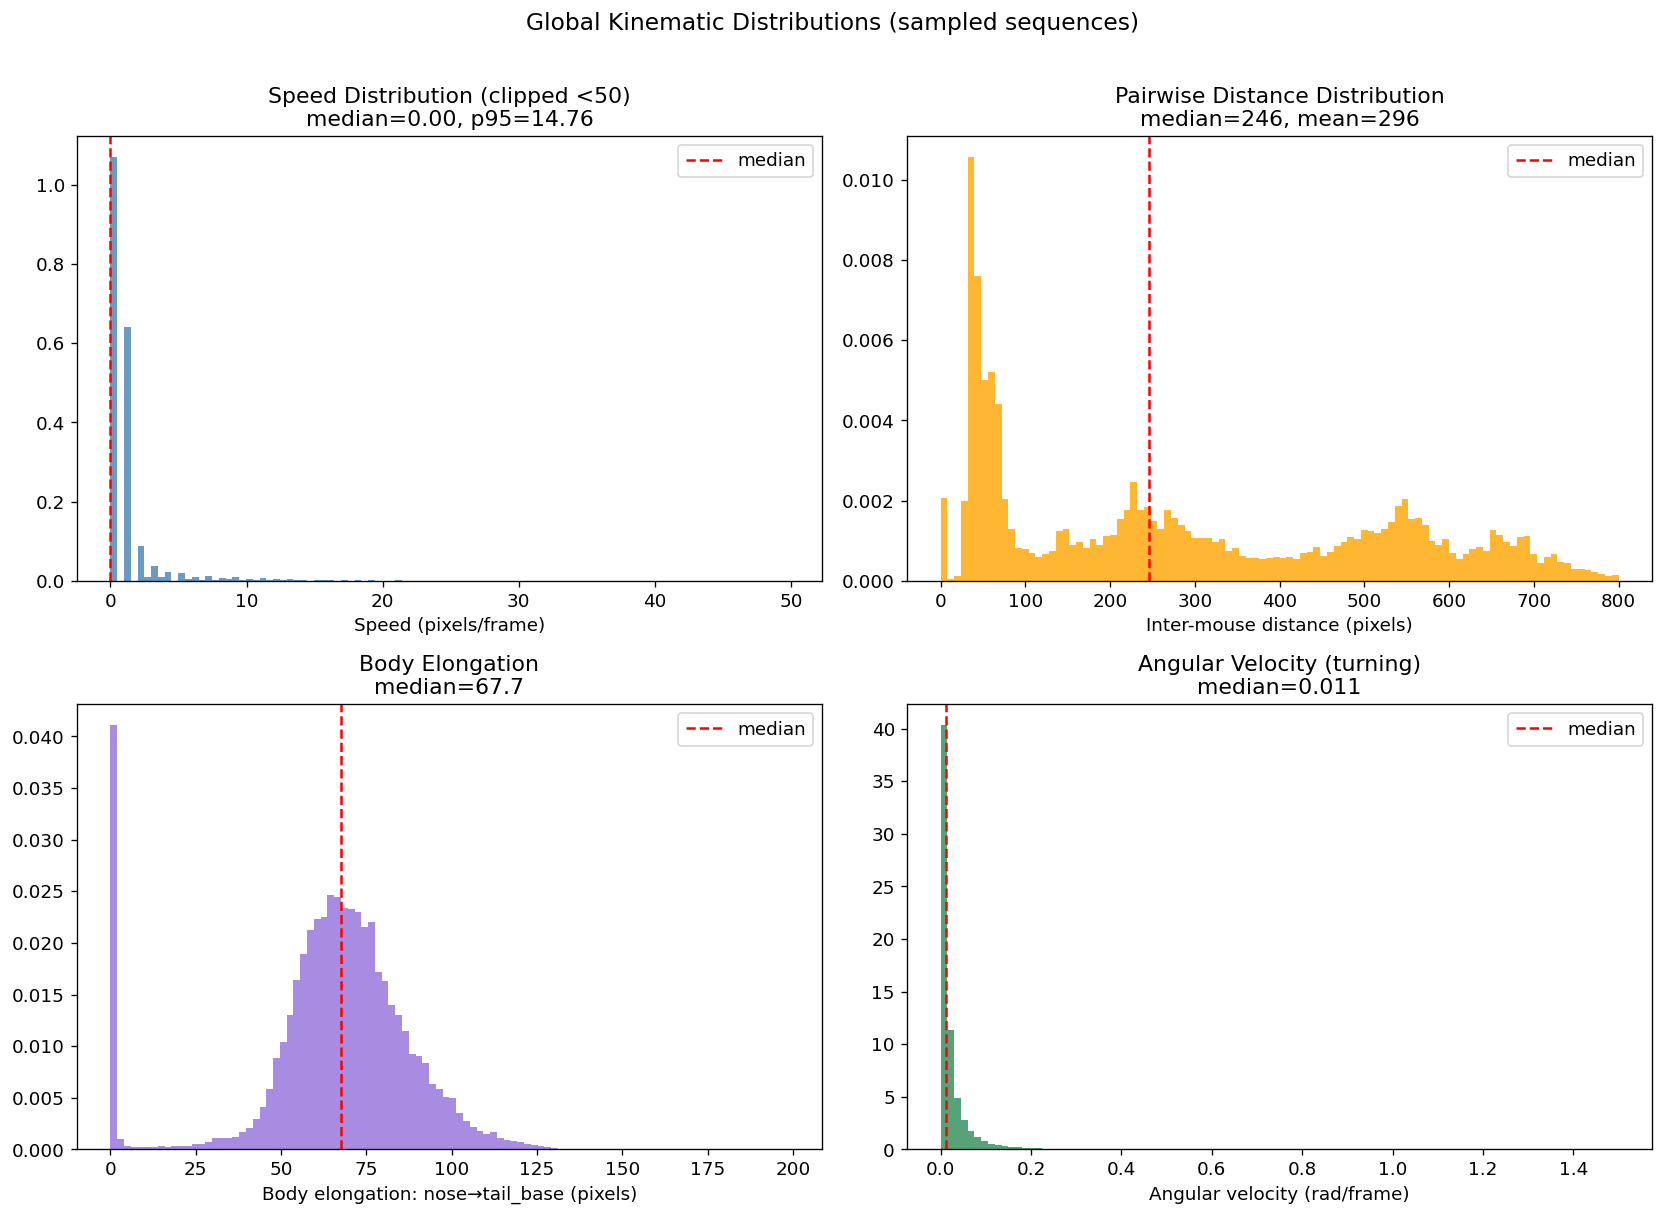

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Speed
axes[0,0].hist(all_speed[all_speed < 50], bins=100, color='steelblue', alpha=0.8, density=True)
axes[0,0].set_xlabel('Speed (pixels/frame)')
axes[0,0].set_title(f'Speed Distribution (clipped <50)\nmedian={np.median(all_speed):.2f}, p95={np.percentile(all_speed, 95):.2f}')
axes[0,0].axvline(np.median(all_speed), color='red', linestyle='--', label='median')
axes[0,0].legend()

# Inter-mouse distance
axes[0,1].hist(all_dist[all_dist < 800], bins=100, color='orange', alpha=0.8, density=True)
axes[0,1].set_xlabel('Inter-mouse distance (pixels)')
axes[0,1].set_title(f'Pairwise Distance Distribution\nmedian={np.median(all_dist):.0f}, mean={np.mean(all_dist):.0f}')
axes[0,1].axvline(np.median(all_dist), color='red', linestyle='--', label='median')
axes[0,1].legend()

# Body elongation
axes[1,0].hist(all_elong[all_elong < 200], bins=100, color='mediumpurple', alpha=0.8, density=True)
axes[1,0].set_xlabel('Body elongation: nose→tail_base (pixels)')
axes[1,0].set_title(f'Body Elongation\nmedian={np.median(all_elong):.1f}')
axes[1,0].axvline(np.median(all_elong), color='red', linestyle='--', label='median')
axes[1,0].legend()

# Angular velocity
axes[1,1].hist(all_angvel[all_angvel < 1.5], bins=100, color='seagreen', alpha=0.8, density=True)
axes[1,1].set_xlabel('Angular velocity (rad/frame)')
axes[1,1].set_title(f'Angular Velocity (turning)\nmedian={np.median(all_angvel):.3f}')
axes[1,1].axvline(np.median(all_angvel), color='red', linestyle='--', label='median')
axes[1,1].legend()

plt.suptitle('Global Kinematic Distributions (sampled sequences)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Chase vs Non-Chase Kinematics

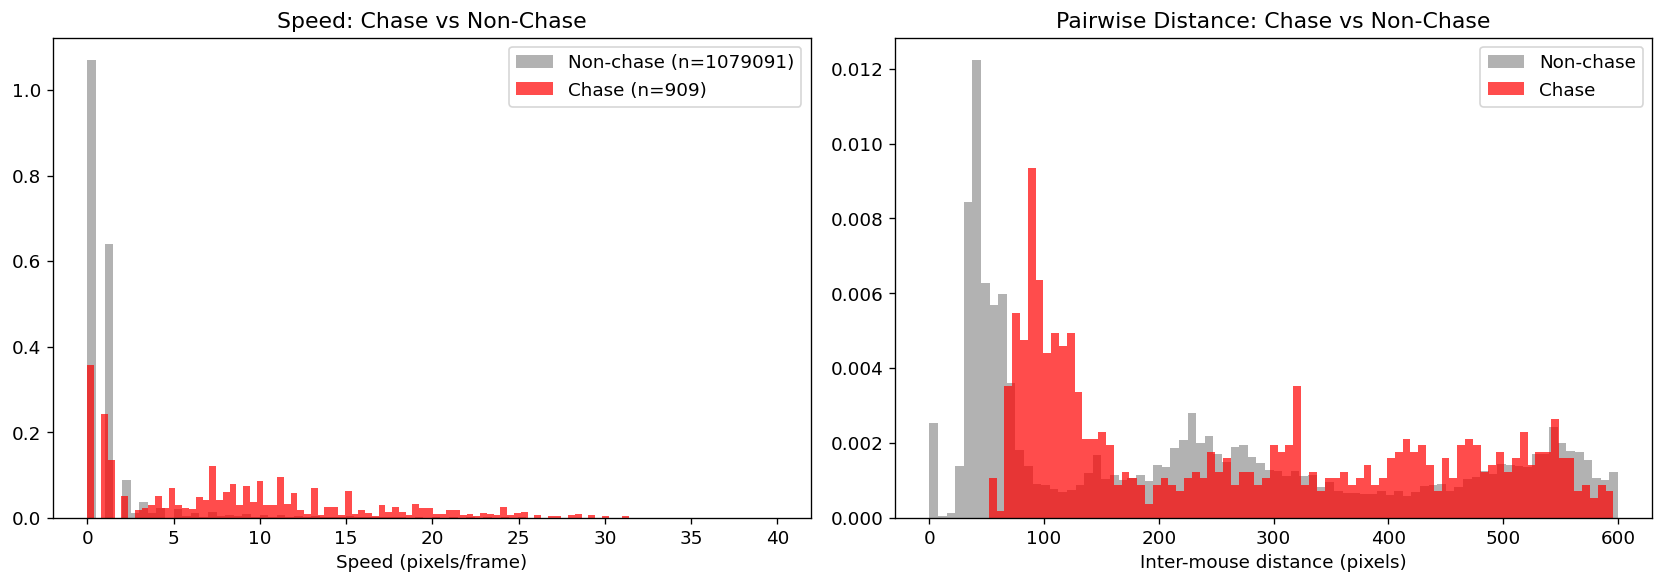

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(all_speed_chase) > 0:
    axes[0].hist(all_speed_nochase[all_speed_nochase < 40], bins=80, alpha=0.6, density=True,
                 color='gray', label=f'Non-chase (n={len(all_speed_nochase)})')
    axes[0].hist(all_speed_chase[all_speed_chase < 40], bins=80, alpha=0.7, density=True,
                 color='red', label=f'Chase (n={len(all_speed_chase)})')
    axes[0].set_xlabel('Speed (pixels/frame)')
    axes[0].set_title('Speed: Chase vs Non-Chase')
    axes[0].legend()
    
    axes[1].hist(all_dist_nochase[all_dist_nochase < 600], bins=80, alpha=0.6, density=True,
                 color='gray', label='Non-chase')
    axes[1].hist(all_dist_chase[all_dist_chase < 600], bins=80, alpha=0.7, density=True,
                 color='red', label='Chase')
    axes[1].set_xlabel('Inter-mouse distance (pixels)')
    axes[1].set_title('Pairwise Distance: Chase vs Non-Chase')
    axes[1].legend()
else:
    axes[0].text(0.5, 0.5, 'No chase frames in sampled sequences', ha='center', va='center', transform=axes[0].transAxes)
    axes[1].text(0.5, 0.5, 'No chase frames in sampled sequences', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

## 6. Lights ON vs OFF Activity

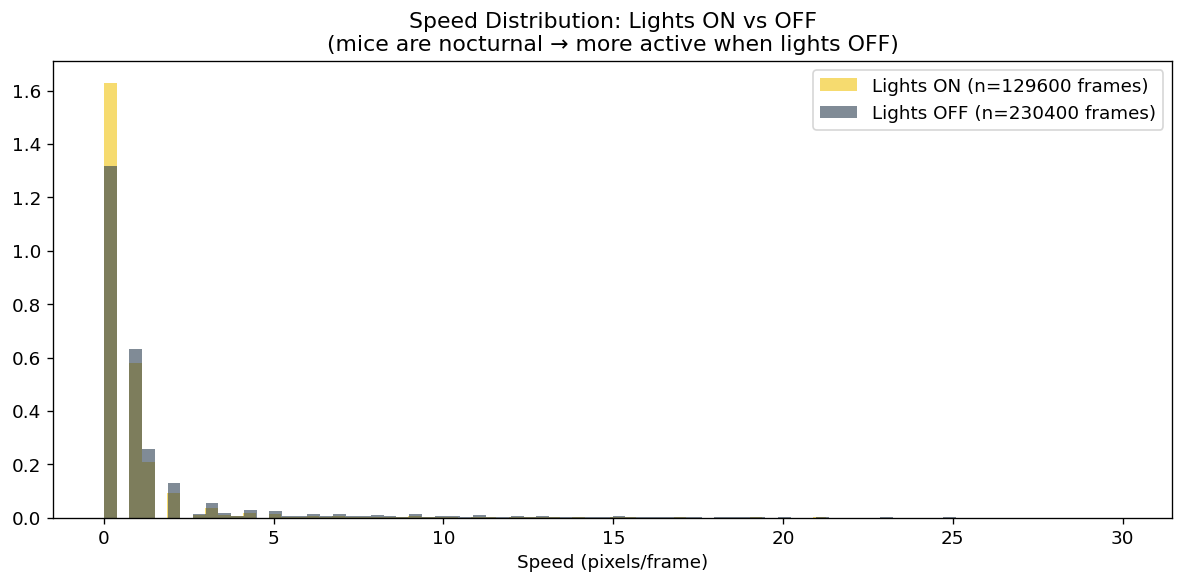

Mean speed - Lights ON: 26.32, Lights OFF: 12.62
Median speed - Lights ON: 0.00, Lights OFF: 1.00


In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

if len(all_speed_lighton) > 0 and len(all_speed_lightoff) > 0:
    ax.hist(all_speed_lighton[all_speed_lighton < 30], bins=80, alpha=0.6, density=True,
            color='#f1c40f', label=f'Lights ON (n={len(all_speed_lighton)//3} frames)')
    ax.hist(all_speed_lightoff[all_speed_lightoff < 30], bins=80, alpha=0.6, density=True,
            color='#2c3e50', label=f'Lights OFF (n={len(all_speed_lightoff)//3} frames)')
    ax.set_xlabel('Speed (pixels/frame)')
    ax.set_title('Speed Distribution: Lights ON vs OFF\n(mice are nocturnal → more active when lights OFF)')
    ax.legend()

plt.tight_layout()
plt.show()

print(f'Mean speed - Lights ON: {np.mean(all_speed_lighton):.2f}, Lights OFF: {np.mean(all_speed_lightoff):.2f}')
print(f'Median speed - Lights ON: {np.median(all_speed_lighton):.2f}, Lights OFF: {np.median(all_speed_lightoff):.2f}')

## 7. Derived Behavior Labels (from kinematics)

Since only `chases` and `lights` are provided, we define additional kinematic-based behavior categories to understand what the data contains:

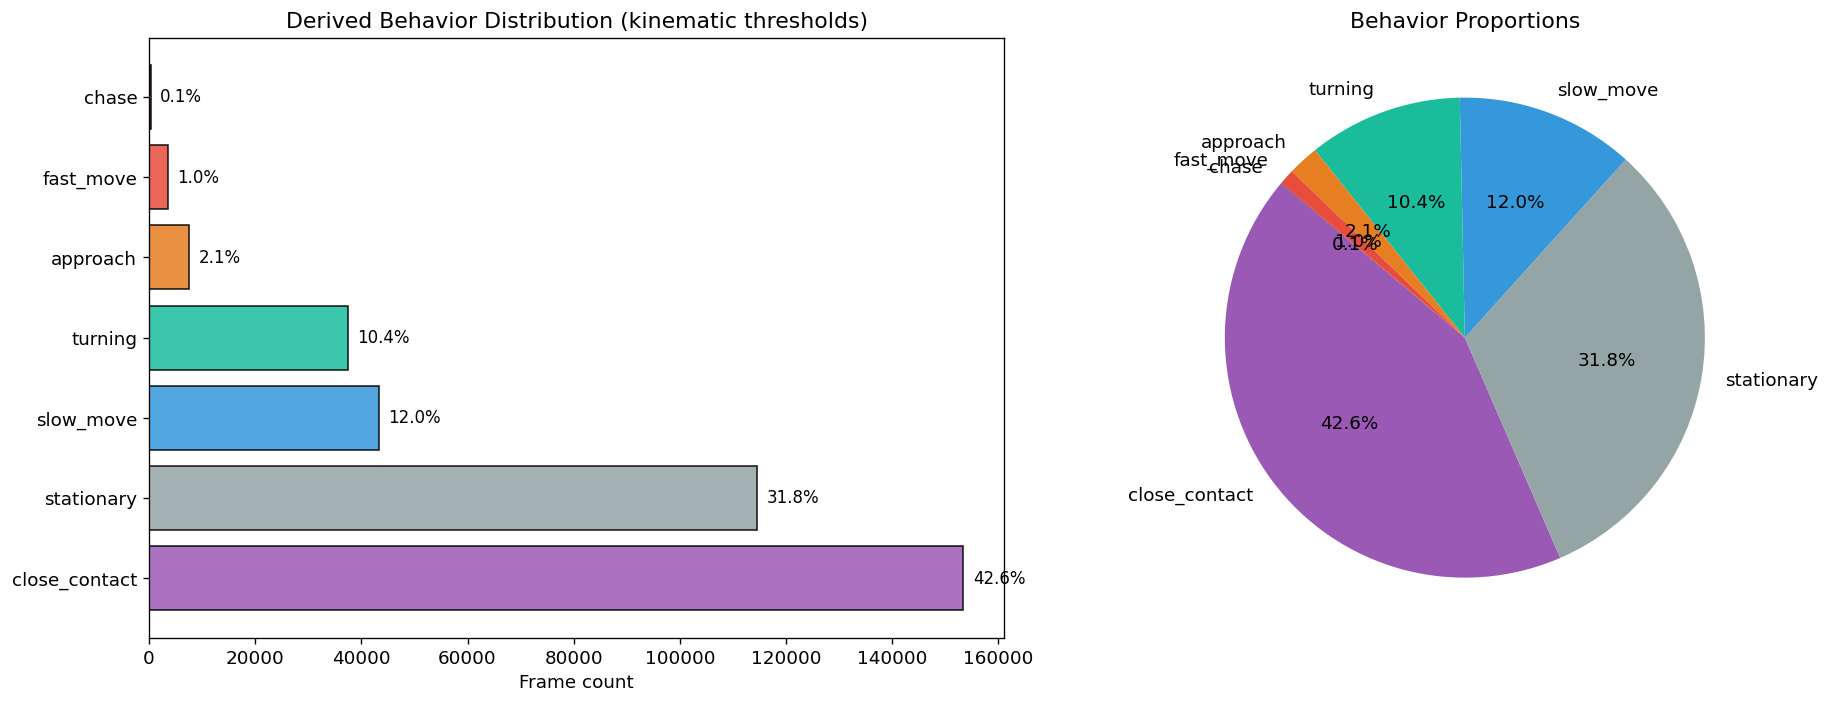

  close_contact  :   153412 frames ( 42.6%)
  stationary     :   114493 frames ( 31.8%)
  slow_move      :    43306 frames ( 12.0%)
  turning        :    37440 frames ( 10.4%)
  approach       :     7488 frames (  2.1%)
  fast_move      :     3558 frames (  1.0%)
  chase          :      303 frames (  0.1%)


In [10]:
def classify_behavior(kp, ann_chase):
    """Derive frame-level behavior categories from kinematics."""
    T = kp.shape[0]
    kin = compute_kinematics(kp)
    
    labels = np.full(T, 'stationary', dtype=object)
    
    avg_speed = np.mean(kin['speed'], axis=1)           # mean across 3 mice
    min_dist  = np.min(kin['pair_dist'], axis=1)        # closest pair
    max_angvel = np.max(kin['ang_vel'], axis=1)         # fastest turning mouse
    
    # Thresholds (empirical, in pixels at 30Hz)
    labels[avg_speed > 2]   = 'slow_move'
    labels[avg_speed > 8]   = 'fast_move'
    labels[(min_dist < 60) & (avg_speed < 3)]  = 'close_contact'
    labels[(min_dist < 80) & (avg_speed > 5)]  = 'approach'
    labels[max_angvel > 0.5] = 'turning'
    labels[ann_chase == 1]  = 'chase'  # override with ground truth
    
    return labels

# Classify all sampled sequences
behavior_counts = defaultdict(int)
for sid in sample_ids:
    kp = np.array(seqs[sid]['keypoints']).astype(float)
    ann_chase = np.array(seqs[sid]['annotations'][0])
    labels = classify_behavior(kp, ann_chase)
    for l in labels:
        behavior_counts[l] += 1

# Plot
cats = sorted(behavior_counts.keys(), key=lambda x: -behavior_counts[x])
counts = [behavior_counts[c] for c in cats]
total = sum(counts)

colors_map = {'stationary': '#95a5a6', 'slow_move': '#3498db', 'fast_move': '#e74c3c',
              'close_contact': '#9b59b6', 'approach': '#e67e22', 'turning': '#1abc9c', 'chase': '#c0392b'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bar_colors = [colors_map.get(c, '#bdc3c7') for c in cats]
bars = axes[0].barh(cats, counts, color=bar_colors, edgecolor='black', alpha=0.85)
for bar, c in zip(bars, counts):
    axes[0].text(bar.get_width() + total*0.005, bar.get_y() + bar.get_height()/2,
                 f'{c/total*100:.1f}%', va='center', fontsize=10)
axes[0].set_xlabel('Frame count')
axes[0].set_title('Derived Behavior Distribution (kinematic thresholds)')

# Pie chart
axes[1].pie(counts, labels=cats, colors=bar_colors, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Behavior Proportions')

plt.tight_layout()
plt.show()

for c in cats:
    print(f'  {c:15s}: {behavior_counts[c]:>8d} frames ({behavior_counts[c]/total*100:5.1f}%)')

## 8. Spatial Occupancy Heatmap

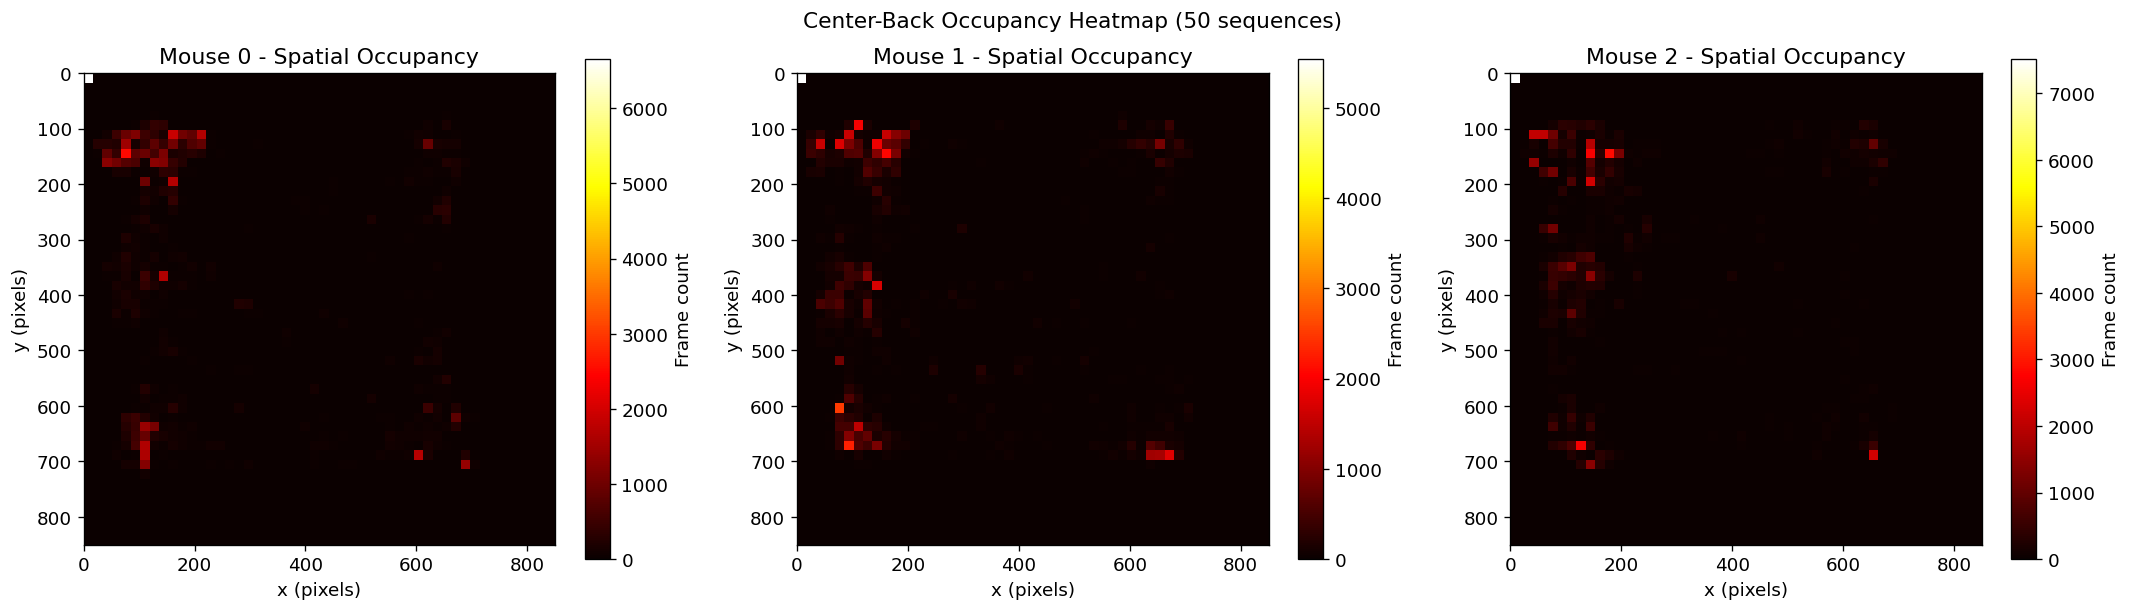

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for m_idx in range(3):
    all_x, all_y = [], []
    for sid in sample_ids[:50]:
        kp = np.array(seqs[sid]['keypoints']).astype(float)
        all_x.append(kp[:, m_idx, 6, 0])  # center_back x
        all_y.append(kp[:, m_idx, 6, 1])  # center_back y
    all_x = np.concatenate(all_x)
    all_y = np.concatenate(all_y)
    
    h = axes[m_idx].hist2d(all_x, all_y, bins=50, range=[[0,850],[0,850]], cmap='hot')
    axes[m_idx].set_title(f'{MOUSE_NAMES[m_idx]} - Spatial Occupancy')
    axes[m_idx].set_xlabel('x (pixels)')
    axes[m_idx].set_ylabel('y (pixels)')
    axes[m_idx].set_aspect('equal')
    axes[m_idx].invert_yaxis()
    plt.colorbar(h[3], ax=axes[m_idx], label='Frame count')

plt.suptitle('Center-Back Occupancy Heatmap (50 sequences)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Single-Frame Pose Visualization (using project Visualiser style)

In [12]:
def plot_mouse_pose(ax, pose, color, label=None):
    """Plot one mouse's 12-keypoint skeleton on ax."""
    ax.plot(pose[:, 0], pose[:, 1], 'o', color=color, markersize=4, zorder=5)
    for (i, j) in SKELETON:
        ax.plot(pose[[i,j], 0], pose[[i,j], 1], color=color, linewidth=1.5, alpha=0.7)
    # Annotate nose
    ax.annotate('', xy=(pose[0,0], pose[0,1]),
                xytext=(pose[3,0], pose[3,1]),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    if label:
        ax.text(pose[6,0]+5, pose[6,1]-5, label, color=color, fontsize=9, fontweight='bold')

def visualize_frame(kp, frame_idx, title='', ax=None):
    """Visualize a single frame with all 3 mice."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    ax.set_xlim(0, 850)
    ax.set_ylim(850, 0)
    ax.set_aspect('equal')
    ax.set_facecolor('#1a1a2e')
    
    for m in range(3):
        plot_mouse_pose(ax, kp[frame_idx, m], MOUSE_COLORS[m], MOUSE_NAMES[m])
    
    ax.set_title(f'{title} (frame {frame_idx})', fontsize=11)
    ax.set_xlabel('x (pixels)')
    ax.set_ylabel('y (pixels)')
    return ax

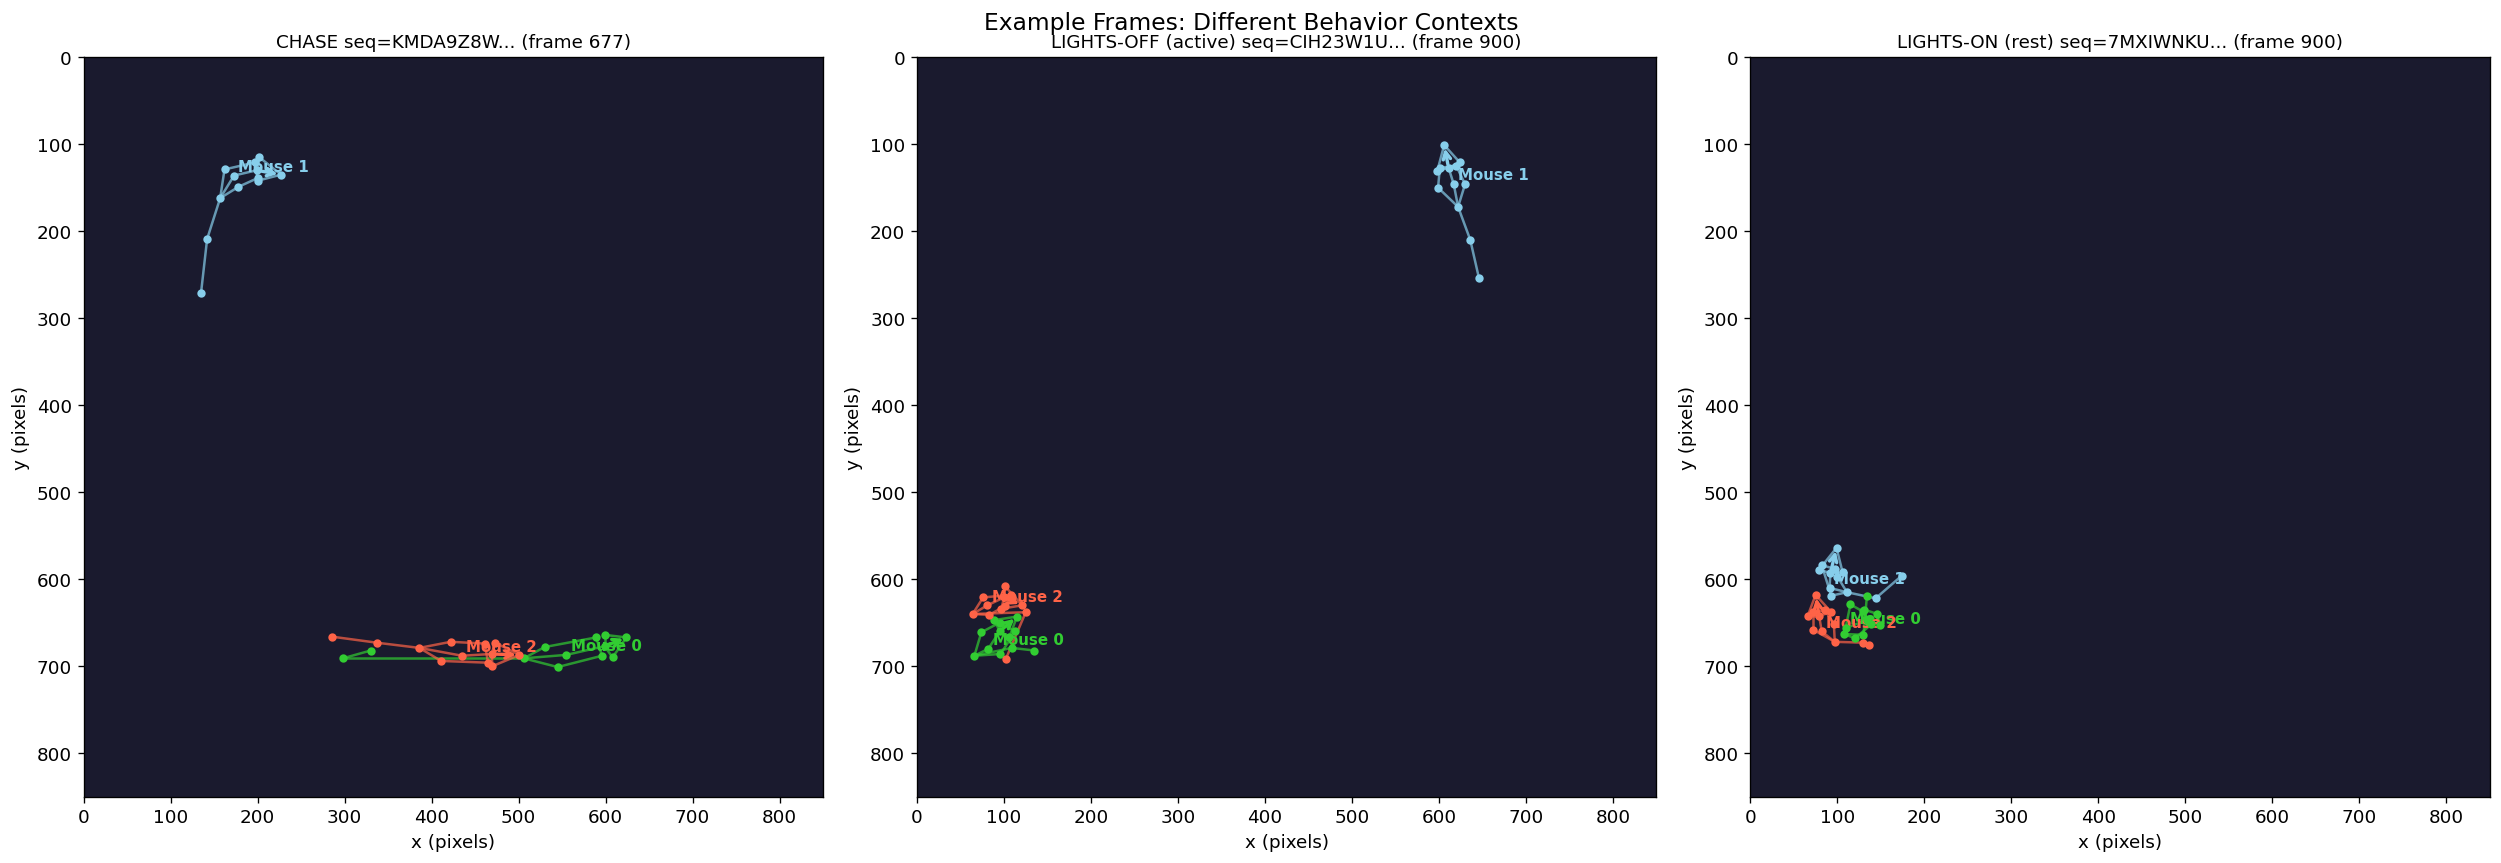

In [13]:
# Show example frames from different behavior categories
# Find a chase sequence
chase_seqs = [sid for sid in seq_ids if np.sum(np.array(seqs[sid]['annotations'][0]) == 1) > 0]
nochase_seqs = [sid for sid in seq_ids if np.sum(np.array(seqs[sid]['annotations'][0]) == 1) == 0]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

# Chase frame
if chase_seqs:
    sid = chase_seqs[0]
    kp = np.array(seqs[sid]['keypoints']).astype(float)
    ann = np.array(seqs[sid]['annotations'][0])
    chase_frames = np.where(ann == 1)[0]
    visualize_frame(kp, chase_frames[len(chase_frames)//2], f'CHASE seq={sid[:8]}...', axes[0])

# Active non-chase (lights OFF)
off_seqs = [sid for sid in nochase_seqs if np.array(seqs[sid]['annotations'][1])[0] == 0]
if off_seqs:
    sid = off_seqs[0]
    kp = np.array(seqs[sid]['keypoints']).astype(float)
    visualize_frame(kp, 900, f'LIGHTS-OFF (active) seq={sid[:8]}...', axes[1])

# Inactive (lights ON)
on_seqs = [sid for sid in nochase_seqs if np.array(seqs[sid]['annotations'][1])[0] == 1]
if on_seqs:
    sid = on_seqs[0]
    kp = np.array(seqs[sid]['keypoints']).astype(float)
    visualize_frame(kp, 900, f'LIGHTS-ON (rest) seq={sid[:8]}...', axes[2])

plt.suptitle('Example Frames: Different Behavior Contexts', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Trajectory Visualization (multi-frame)

In [14]:
def plot_trajectory_segment(kp, start, length, ann_chase=None, title='', ax=None):
    """Plot trajectories of 3 mice over a segment, with behavior coloring."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    
    ax.set_xlim(0, 850)
    ax.set_ylim(850, 0)
    ax.set_aspect('equal')
    ax.set_facecolor('#f0f0f0')
    
    end = min(start + length, kp.shape[0])
    
    for m in range(3):
        traj = kp[start:end, m, 6, :]  # center_back trajectory
        
        if ann_chase is not None:
            for t in range(len(traj) - 1):
                if ann_chase[start + t] == 1:
                    ax.plot(traj[t:t+2, 0], traj[t:t+2, 1], color='red', linewidth=2.5, alpha=0.9)
                else:
                    ax.plot(traj[t:t+2, 0], traj[t:t+2, 1], color=MOUSE_COLORS[m], linewidth=1, alpha=0.5)
        else:
            ax.plot(traj[:, 0], traj[:, 1], color=MOUSE_COLORS[m], linewidth=1, alpha=0.6)
        
        # Start and end markers
        ax.plot(traj[0, 0], traj[0, 1], 'o', color=MOUSE_COLORS[m], markersize=8, zorder=10)
        ax.plot(traj[-1, 0], traj[-1, 1], 's', color=MOUSE_COLORS[m], markersize=8, zorder=10)
        # Final pose
        plot_mouse_pose(ax, kp[end-1, m], MOUSE_COLORS[m])
    
    legend_elements = [mpatches.Patch(color=c, label=n) for c, n in zip(MOUSE_COLORS, MOUSE_NAMES)]
    if ann_chase is not None:
        legend_elements.append(mpatches.Patch(color='red', label='Chase'))
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    ax.set_title(f'{title}\nframes {start}-{end} ({(end-start)/30:.1f}s)', fontsize=11)
    return ax

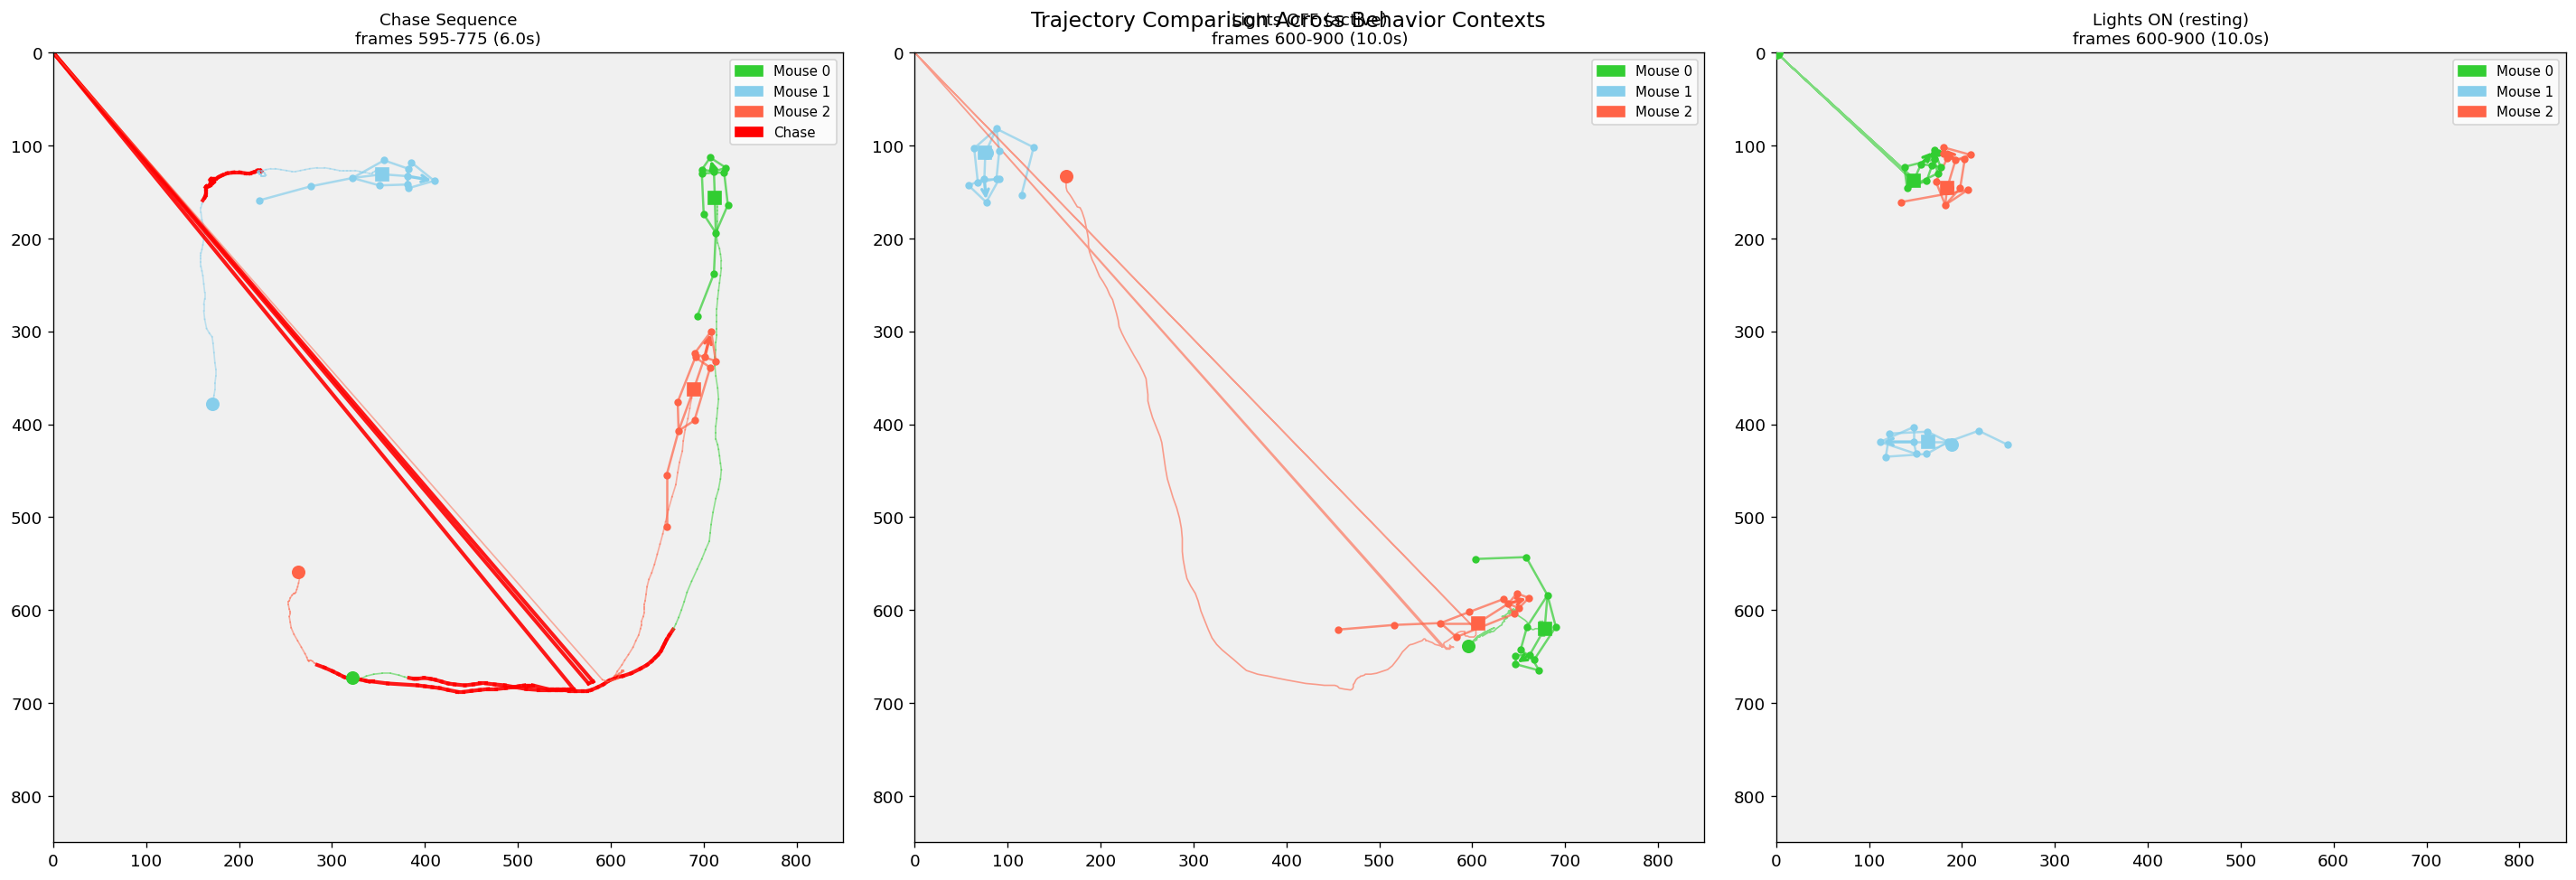

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Chase trajectory
if chase_seqs:
    sid = chase_seqs[0]
    kp = np.array(seqs[sid]['keypoints']).astype(float)
    ann = np.array(seqs[sid]['annotations'][0])
    chase_start = np.where(ann == 1)[0][0]
    plot_trajectory_segment(kp, max(0, chase_start - 60), 180, ann, 'Chase Sequence', axes[0])

# Active (lights off, no chase)
if off_seqs:
    sid = off_seqs[np.random.randint(len(off_seqs))]
    kp = np.array(seqs[sid]['keypoints']).astype(float)
    plot_trajectory_segment(kp, 600, 300, title='Lights OFF (active)', ax=axes[1])

# Resting (lights on)
if on_seqs:
    sid = on_seqs[np.random.randint(len(on_seqs))]
    kp = np.array(seqs[sid]['keypoints']).astype(float)
    plot_trajectory_segment(kp, 600, 300, title='Lights ON (resting)', ax=axes[2])

plt.suptitle('Trajectory Comparison Across Behavior Contexts', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Time-Series Kinematic Profile for a Chase Sequence

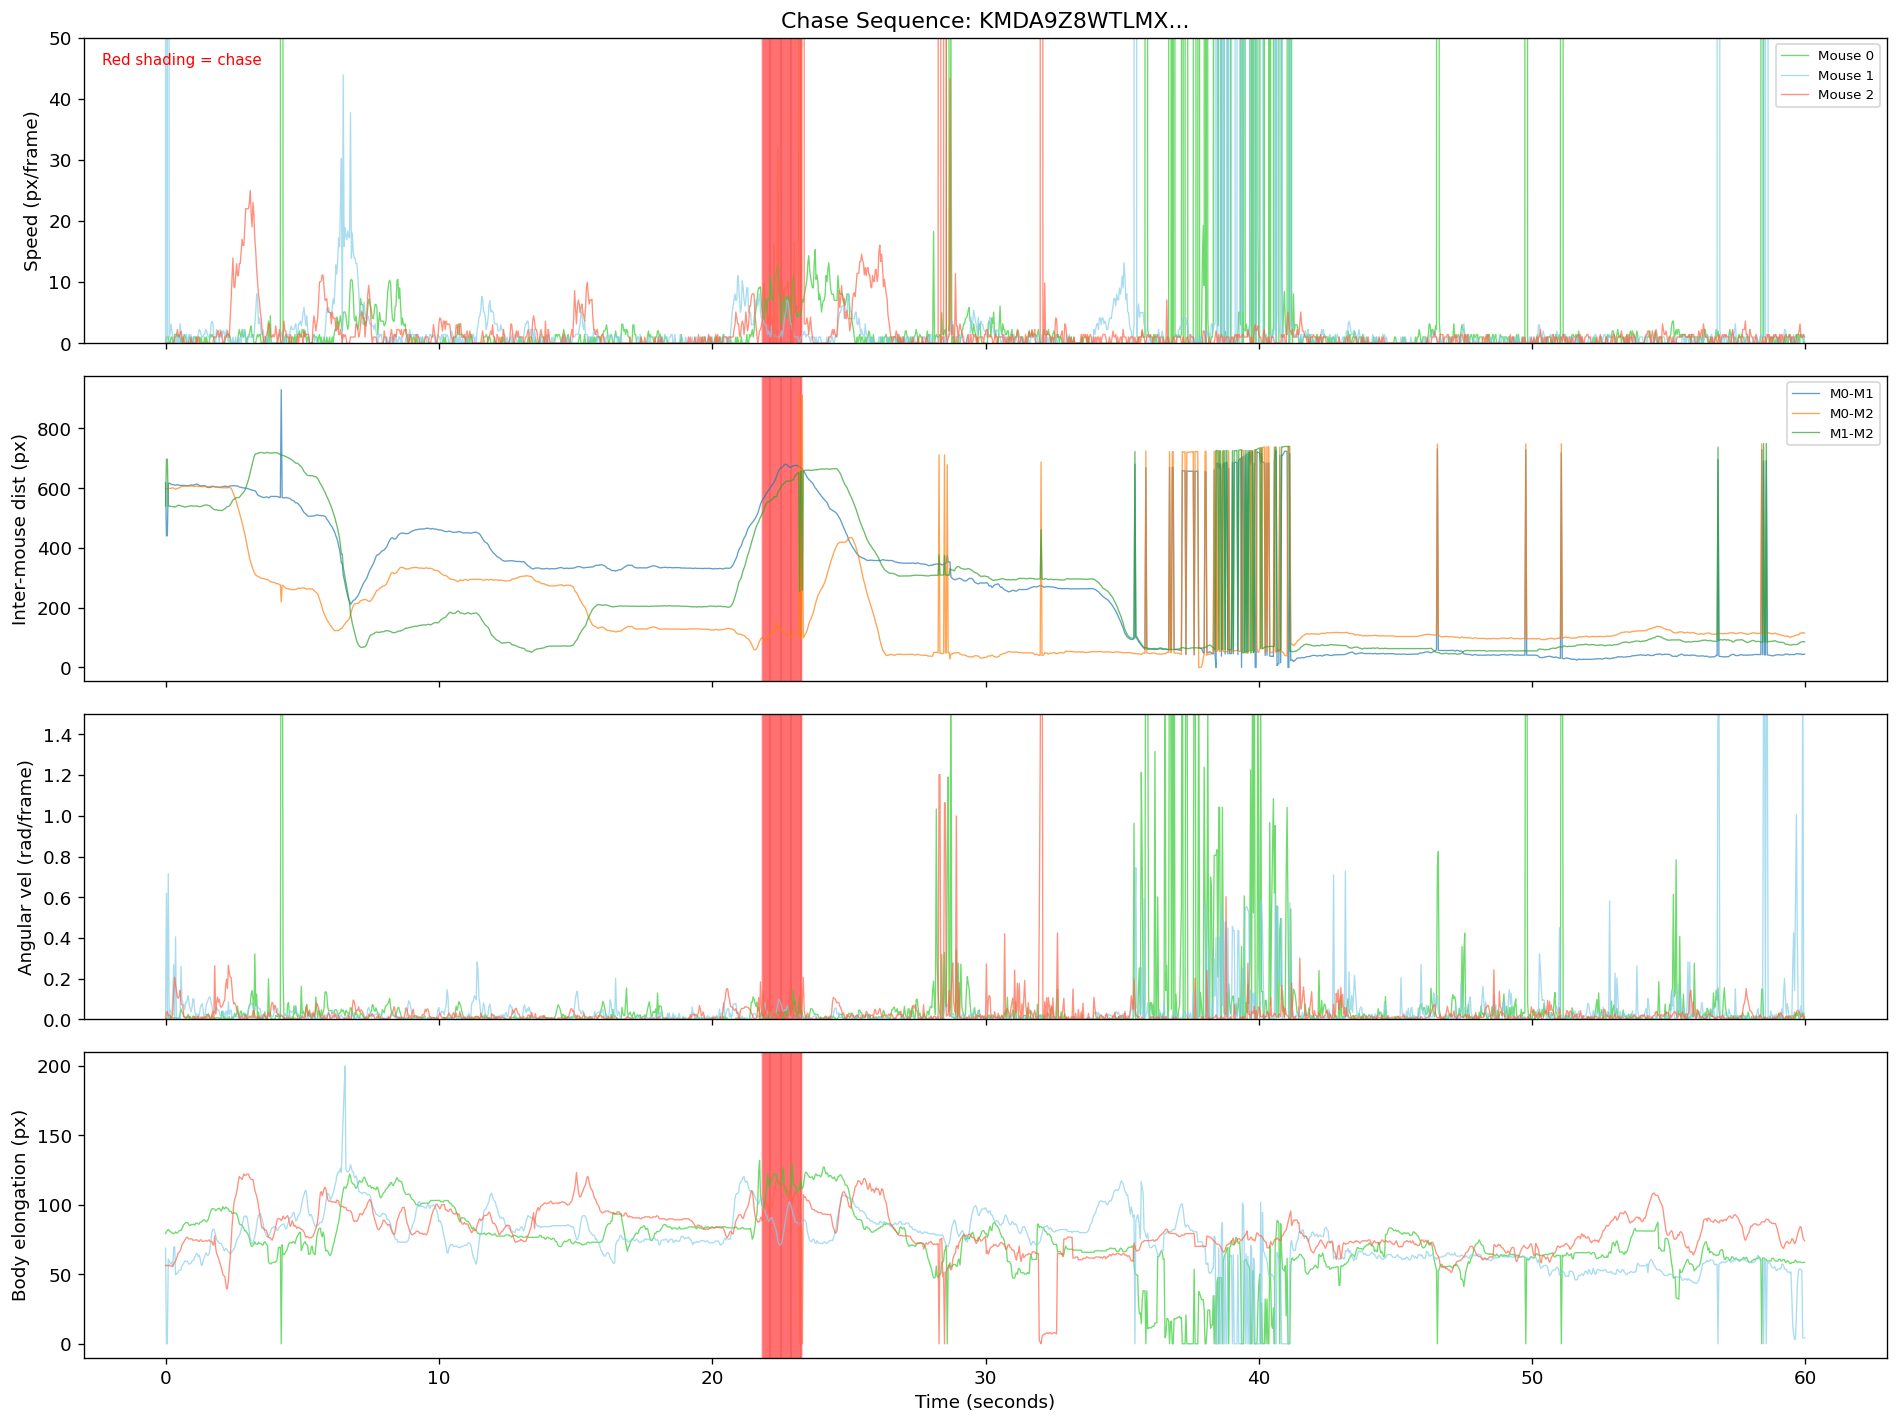

In [16]:
if chase_seqs:
    sid = chase_seqs[0]
    kp = np.array(seqs[sid]['keypoints']).astype(float)
    ann_chase = np.array(seqs[sid]['annotations'][0])
    kin = compute_kinematics(kp)
    
    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
    t = np.arange(1800) / 30.0  # seconds
    
    # Highlight chase regions
    for ax in axes:
        chase_mask = (ann_chase == 1)
        for i in range(len(chase_mask)):
            if chase_mask[i]:
                ax.axvspan(t[i], t[min(i+1, len(t)-1)], alpha=0.2, color='red')
    
    # Speed
    for m in range(3):
        axes[0].plot(t, kin['speed'][:, m], color=MOUSE_COLORS[m], alpha=0.7, linewidth=0.8, label=MOUSE_NAMES[m])
    axes[0].set_ylabel('Speed (px/frame)')
    axes[0].set_title(f'Chase Sequence: {sid[:12]}...')
    axes[0].legend(loc='upper right', fontsize=8)
    axes[0].set_ylim(0, 50)
    
    # Pairwise distance
    for i, name in enumerate(kin['pair_names']):
        axes[1].plot(t, kin['pair_dist'][:, i], alpha=0.7, linewidth=0.8, label=name)
    axes[1].set_ylabel('Inter-mouse dist (px)')
    axes[1].legend(loc='upper right', fontsize=8)
    
    # Angular velocity
    for m in range(3):
        axes[2].plot(t, kin['ang_vel'][:, m], color=MOUSE_COLORS[m], alpha=0.7, linewidth=0.8)
    axes[2].set_ylabel('Angular vel (rad/frame)')
    axes[2].set_ylim(0, 1.5)
    
    # Body elongation
    for m in range(3):
        axes[3].plot(t, kin['elongation'][:, m], color=MOUSE_COLORS[m], alpha=0.7, linewidth=0.8)
    axes[3].set_ylabel('Body elongation (px)')
    axes[3].set_xlabel('Time (seconds)')
    
    # Add chase label
    axes[0].text(0.01, 0.95, 'Red shading = chase', transform=axes[0].transAxes,
                 fontsize=9, color='red', va='top')
    
    plt.tight_layout()
    plt.show()
else:
    print('No chase sequences found in dataset')

## 12. What the Current Pipeline Actually Sees

Comparison: full data vs chase-filtered data vs what enters the model.

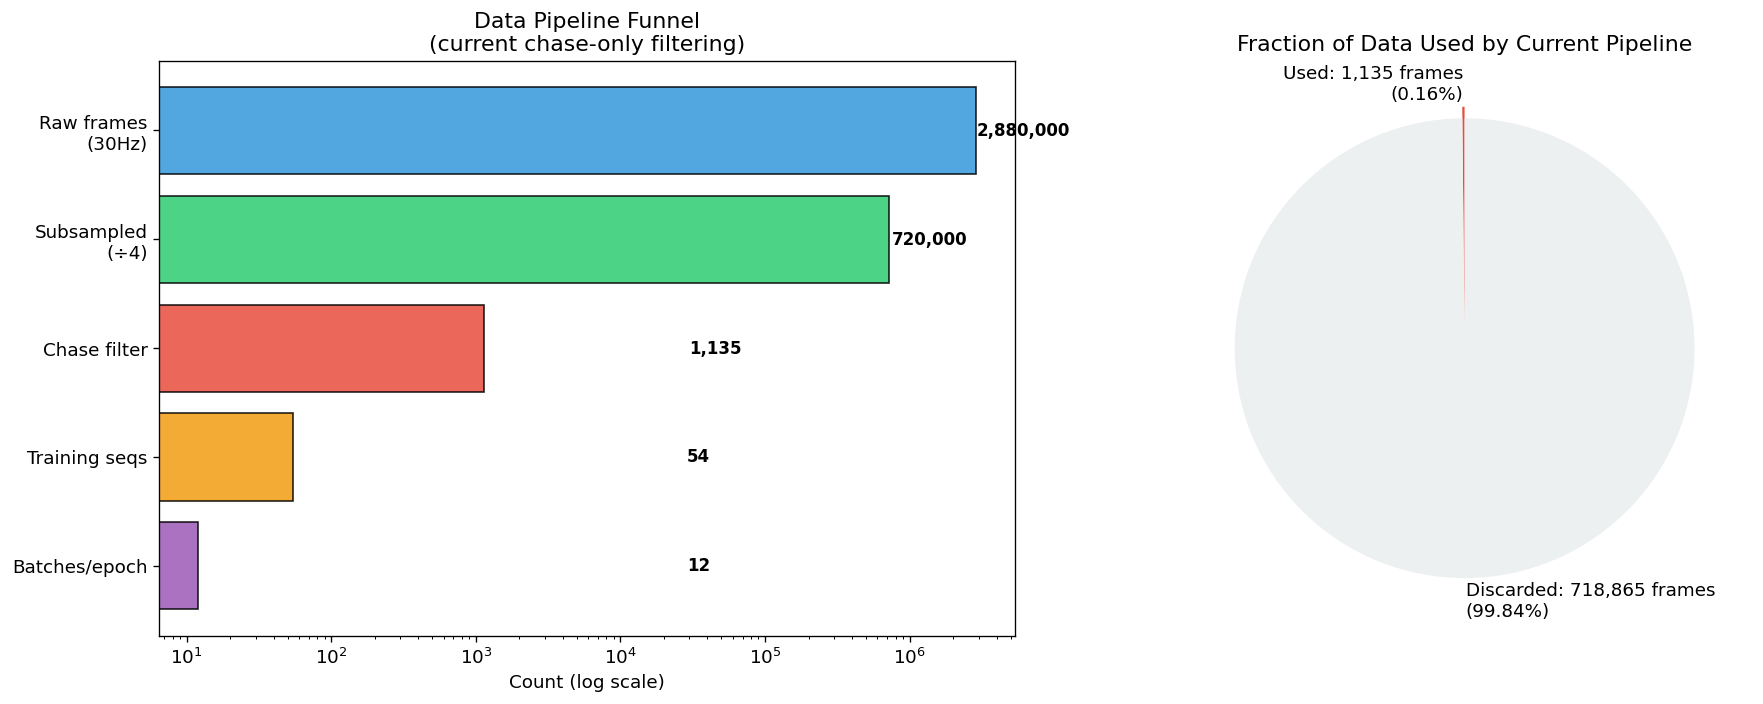

Pipeline summary:
  1600 sequences × 1800 frames = 2,880,000 raw frames
  After ÷4 subsample: 720,000 frames
  After chase filter: 1,135 frames from 34 sequences
  → 54 training sequences → 12 batches/epoch
  → Data utilization: 0.1576%


In [17]:
# Simulate the pipeline data filtering
seq_length = 21
frame_subsample = 4
batch_size = 8

total_seqs = len(seq_ids)
total_frames_raw = total_seqs * 1800
total_frames_sub = total_seqs * (1800 // frame_subsample)

# Chase filter
surviving_seqs = 0
surviving_frames = 0
for sid in seq_ids:
    ann = np.array(seqs[sid]['annotations'][0])
    ann_sub = ann[::frame_subsample]
    chase_ind = np.where(ann_sub == 1)[0]
    if len(chase_ind) == 0:
        continue
    surviving_seqs += 1
    window = seq_length // 2
    frames = set()
    for f in chase_ind:
        frames.update(range(max(0, f - window), min(1800//frame_subsample, f + window)))
    surviving_frames += len(frames)

n_train_sequences = int(surviving_frames / seq_length)
n_train_batches = int(n_train_sequences / batch_size) * 2

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Funnel chart
stages = ['Raw frames\n(30Hz)', f'Subsampled\n(÷{frame_subsample})', 'Chase filter', 'Training seqs', 'Batches/epoch']
values = [total_frames_raw, total_frames_sub, surviving_frames, n_train_sequences, n_train_batches]
colors_f = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

bars = axes[0].barh(stages[::-1], values[::-1], color=colors_f[::-1], edgecolor='black', alpha=0.85)
for bar, v in zip(bars, values[::-1]):
    axes[0].text(bar.get_width() + max(values)*0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:,}', va='center', fontsize=10, fontweight='bold')
axes[0].set_xscale('log')
axes[0].set_xlabel('Count (log scale)')
axes[0].set_title('Data Pipeline Funnel\n(current chase-only filtering)')

# Pie: used vs discarded
axes[1].pie([surviving_frames, total_frames_sub - surviving_frames],
            labels=[f'Used: {surviving_frames:,} frames\n({surviving_frames/total_frames_sub*100:.2f}%)',
                    f'Discarded: {total_frames_sub-surviving_frames:,} frames\n({(1-surviving_frames/total_frames_sub)*100:.2f}%)'],
            colors=['#e74c3c', '#ecf0f1'], explode=(0.05, 0),
            autopct='', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Fraction of Data Used by Current Pipeline')

plt.tight_layout()
plt.show()

print(f'Pipeline summary:')
print(f'  {total_seqs} sequences × 1800 frames = {total_frames_raw:,} raw frames')
print(f'  After ÷{frame_subsample} subsample: {total_frames_sub:,} frames')
print(f'  After chase filter: {surviving_frames:,} frames from {surviving_seqs} sequences')
print(f'  → {n_train_sequences} training sequences → {n_train_batches} batches/epoch')
print(f'  → Data utilization: {surviving_frames/total_frames_sub*100:.4f}%')

## 13. Graph Structure Visualization

Show how the current ST_GRAPH treats mouse keypoints as "pedestrians" and the edge explosion problem.

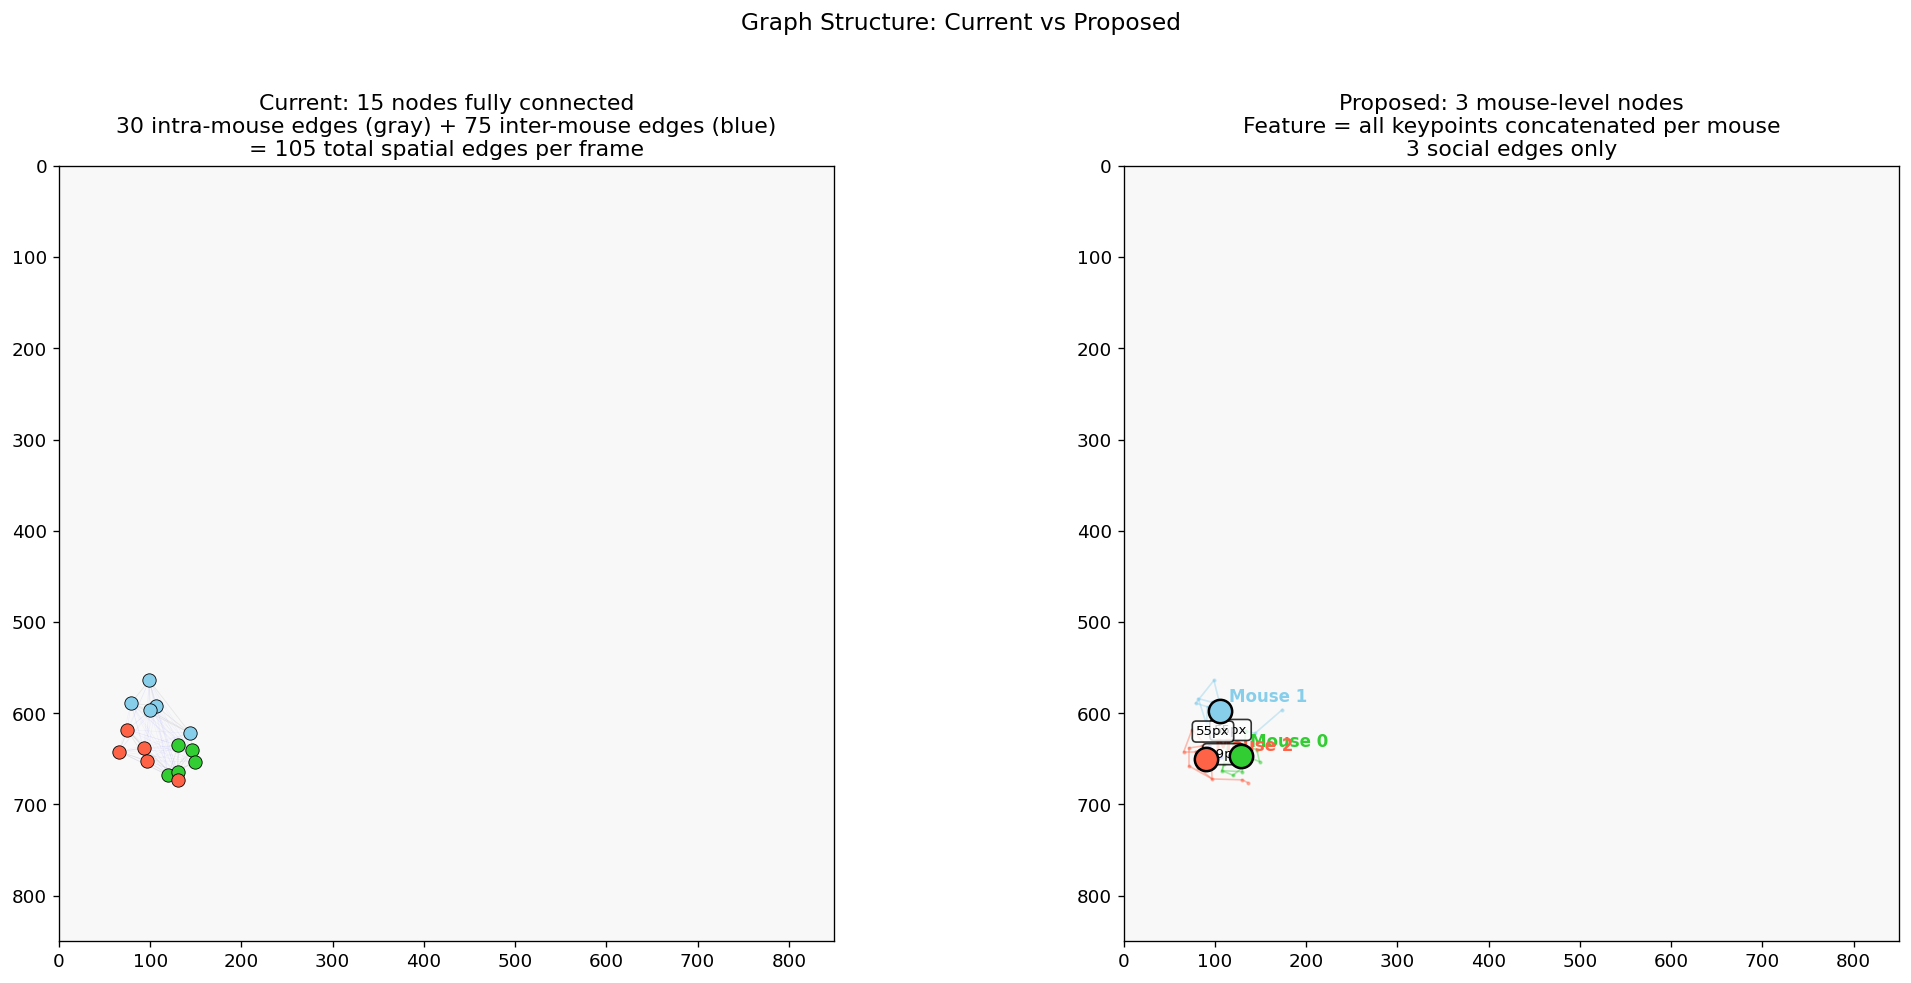

In [20]:
# Current pipeline: 5 selected keypoints × 3 mice = 15 nodes, all-pairs edges
selected_kps = [0, 1, 2, 7, 10]  # nose, left_ear, right_ear, left_hindpaw, tail_middle
kp_names_short = ['nose', 'L_ear', 'R_ear', 'L_hind', 'tail_m']

sid = seq_ids[0]
kp = np.array(seqs[sid]['keypoints']).astype(float)
frame = 900

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# LEFT: Current graph (all 15 nodes fully connected)
ax = axes[0]
ax.set_xlim(0, 850)
ax.set_ylim(850, 0)
ax.set_aspect('equal')
ax.set_facecolor('#f8f8f8')

node_positions = []
node_labels = []
node_colors_list = []

for m in range(3):
    for ki, kp_idx in enumerate(selected_kps):
        pos = kp[frame, m, kp_idx]
        node_positions.append(pos)
        node_labels.append(f'M{m}_{kp_names_short[ki]}')
        node_colors_list.append(MOUSE_COLORS[m])

node_positions = np.array(node_positions)
n_nodes = len(node_positions)

# Draw ALL edges (current pipeline)
n_intra = 0; n_inter = 0
for i in range(n_nodes):
    for j in range(i+1, n_nodes):
        mouse_i = i // len(selected_kps)
        mouse_j = j // len(selected_kps)
        if mouse_i == mouse_j:
            ax.plot([node_positions[i,0], node_positions[j,0]],
                    [node_positions[i,1], node_positions[j,1]],
                    color='gray', alpha=0.15, linewidth=0.5)
            n_intra += 1
        else:
            ax.plot([node_positions[i,0], node_positions[j,0]],
                    [node_positions[i,1], node_positions[j,1]],
                    color='blue', alpha=0.05, linewidth=0.3)
            n_inter += 1

for i, (pos, lbl, c) in enumerate(zip(node_positions, node_labels, node_colors_list)):
    ax.plot(pos[0], pos[1], 'o', color=c, markersize=8, zorder=10, markeredgecolor='black', markeredgewidth=0.5)

ax.set_title(f'Current: 15 nodes fully connected\n{n_intra} intra-mouse edges (gray) + {n_inter} inter-mouse edges (blue)\n= {n_intra+n_inter} total spatial edges per frame')

# RIGHT: Proposed graph (3 mouse nodes)
ax = axes[1]
ax.set_xlim(0, 850)
ax.set_ylim(850, 0)
ax.set_aspect('equal')
ax.set_facecolor('#f8f8f8')

for m in range(3):
    # Draw all keypoints as small dots
    for kp_idx in range(12):
        pos = kp[frame, m, kp_idx]
        ax.plot(pos[0], pos[1], '.', color=MOUSE_COLORS[m], markersize=3, alpha=0.4)
    # Draw skeleton
    for (i, j) in SKELETON:
        ax.plot(kp[frame, m, [i,j], 0], kp[frame, m, [i,j], 1],
                color=MOUSE_COLORS[m], linewidth=1, alpha=0.4)
    # Center node
    center = np.mean(kp[frame, m, :, :], axis=0)
    ax.plot(center[0], center[1], 'o', color=MOUSE_COLORS[m], markersize=14,
            zorder=10, markeredgecolor='black', markeredgewidth=1.5)
    ax.text(center[0]+10, center[1]-10, MOUSE_NAMES[m], color=MOUSE_COLORS[m],
            fontsize=10, fontweight='bold')

# Draw only inter-mouse edges
centers = [np.mean(kp[frame, m, :, :], axis=0) for m in range(3)]
for i in range(3):
    for j in range(i+1, 3):
        ax.plot([centers[i][0], centers[j][0]], [centers[i][1], centers[j][1]],
                color='blue', linewidth=2, alpha=0.6, linestyle='--')
        mid = (centers[i] + centers[j]) / 2
        dist = np.linalg.norm(centers[i] - centers[j])
        ax.text(mid[0], mid[1], f'{dist:.0f}px', fontsize=8, ha='center', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_title(f'Proposed: 3 mouse-level nodes\nFeature = all keypoints concatenated per mouse\n3 social edges only')

plt.suptitle('Graph Structure: Current vs Proposed', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 14. Per-Sequence Kinematic Summary (for Embedding Reference)

This shows what kind of features a good embedding should capture.

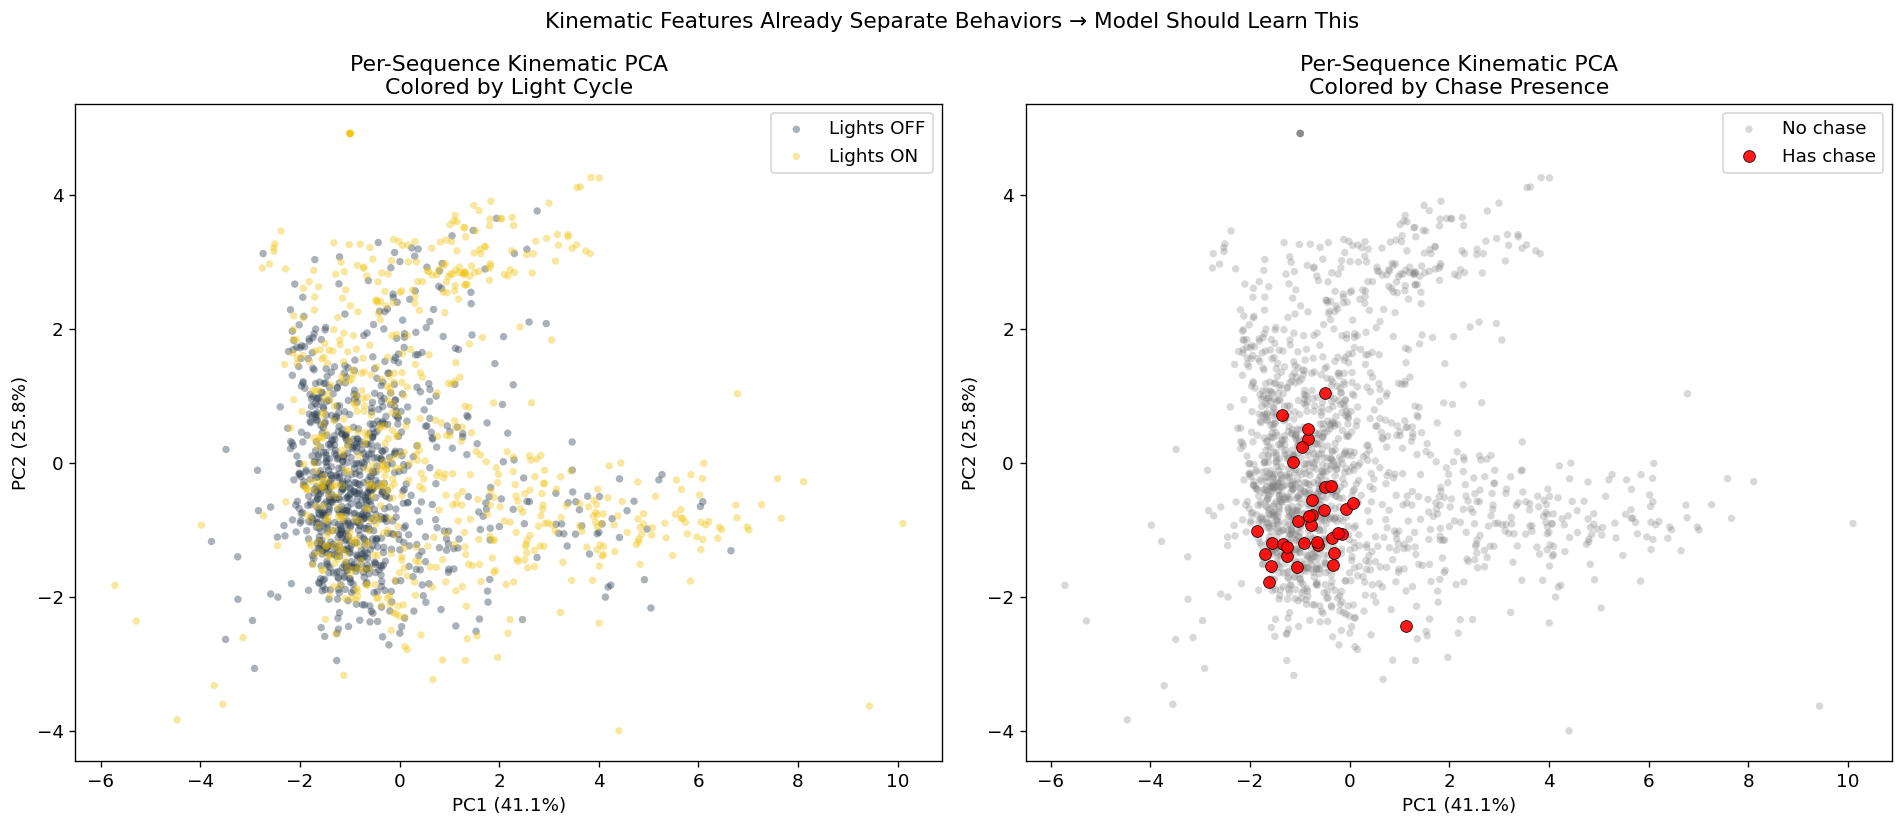

PCA explained variance: [0.41149999 0.25821937]


In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Compute per-sequence summary features
feat_names = ['mean_speed', 'std_speed', 'max_speed',
              'mean_dist', 'std_dist', 'min_dist_p5',
              'mean_angvel', 'mean_elong', 'std_elong']

features = []
light_labels = []
has_chase = []

for sid in seq_ids:
    kp = np.array(seqs[sid]['keypoints']).astype(float)
    ann_light = np.array(seqs[sid]['annotations'][1])[0]
    ann_chase = np.array(seqs[sid]['annotations'][0])
    kin = compute_kinematics(kp)
    
    s = kin['speed']
    d = kin['pair_dist']
    feat = [
        np.mean(s), np.std(s), np.max(s),
        np.mean(d), np.std(d), np.percentile(np.min(d, axis=1), 5),
        np.mean(kin['ang_vel']), np.mean(kin['elongation']), np.std(kin['elongation'])
    ]
    features.append(feat)
    light_labels.append(int(ann_light))
    has_chase.append(1 if np.any(ann_chase == 1) else 0)

features = np.array(features)
light_labels = np.array(light_labels)
has_chase = np.array(has_chase)

# PCA for visualization
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(features_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Color by light cycle
for label, color, name in [(0, '#2c3e50', 'Lights OFF'), (1, '#f1c40f', 'Lights ON')]:
    mask = (light_labels == label)
    axes[0].scatter(pca_coords[mask, 0], pca_coords[mask, 1], c=color, alpha=0.4, s=20, label=name, edgecolors='none')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Per-Sequence Kinematic PCA\nColored by Light Cycle')
axes[0].legend()

# Color by chase presence
mask_nc = (has_chase == 0)
mask_c  = (has_chase == 1)
axes[1].scatter(pca_coords[mask_nc, 0], pca_coords[mask_nc, 1], c='gray', alpha=0.3, s=20, label='No chase', edgecolors='none')
axes[1].scatter(pca_coords[mask_c, 0], pca_coords[mask_c, 1], c='red', alpha=0.9, s=50, label='Has chase', edgecolors='black', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Per-Sequence Kinematic PCA\nColored by Chase Presence')
axes[1].legend()

plt.suptitle('Kinematic Features Already Separate Behaviors → Model Should Learn This', fontsize=13)
plt.tight_layout()
plt.show()

print(f'PCA explained variance: {pca.explained_variance_ratio_}')

## 15. Summary & Key Findings

### Available Labels
| Label | Type | Distribution |
|-------|------|--------------|
| `chases` | frame-level binary | 0.06% positive (极度不平衡) |
| `lights` | sequence-level binary | 42% ON / 58% OFF |

### Derived Behavior Signals (from kinematics)
- **Speed**: clearly separates active/resting, lights ON/OFF
- **Inter-mouse distance**: separates social interaction from independent movement
- **Angular velocity**: indicates turning/exploration
- **Body elongation**: proxy for posture (curled vs stretched)

### Critical Pipeline Issues Confirmed
1. **Chase-only filter discards 99.84% data** → model trains on ~12 batches/epoch
2. **Kinematic PCA shows lights and chase ARE separable** → the data has signal, the model just doesn't see it
3. **Graph treats keypoints as independent pedestrians** → 105 edges, mostly intra-mouse noise